# emotion classification with distilbert

this notebook presents an end-to-end nlp classification project using distilbert fine-tuned on the `dair-ai/emotion` dataset.

## project goals
- build a multi-class emotion classifier from text
- fine-tune a transformer baseline with reproducible settings
- evaluate model quality using accuracy, weighted f1, per-class metrics, and a confusion matrix

## setup

In [91]:
import random
import numpy as np
import torch
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    set_seed,
    )

In [92]:
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [93]:
if torch.cuda.is_available():
    device = "cuda"
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

## data loading and sampling

In [94]:
ds = load_dataset("dair-ai/emotion")

In [95]:
label_names = ds["train"].features["label"].names
num_labels = len(label_names)

In [96]:
full_ds = {
    "train": ds["train"].shuffle(seed=SEED),
    "validation": ds["validation"].shuffle(seed=SEED),
    "test": ds["test"].shuffle(seed=SEED),
}

for split in full_ds:
    print(split, len(full_ds[split]))

train 16000
validation 2000
test 2000


## tokenization and preprocessing

In [97]:
model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

In [98]:
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True)

tokenized_ds = {
    split: full_ds[split].map(tokenize_batch, batched=True)
    for split in ["train", "validation", "test"]
}

In [99]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
for split in tokenized_ds:
    tokenized_ds[split] = tokenized_ds[split].remove_columns(["text"])
    tokenized_ds[split] = tokenized_ds[split].rename_column("label", "labels")
    tokenized_ds[split].set_format("torch")

In [100]:
tokenized_ds["train"][0]

{'labels': tensor(4),
 'input_ids': tensor([ 101, 2096, 9670, 1999, 1996, 2406,  102]),
 'token_type_ids': tensor([0, 0, 0, 0, 0, 0, 0]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1])}

## model definition and training setup

In [101]:
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

In [102]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    )

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6787.01it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [103]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

In [104]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"]
    return {"accuracy": acc, "f1_weighted": f1}

In [105]:
training_args = TrainingArguments(
    output_dir="./emotion-distilbert-checkpoints",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_weighted",
    report_to="none",
    seed=SEED,
    )

In [106]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    )

## fine-tuning run

In [107]:
train_result = trainer.train()
train_result

/Users/akbotaserikkyzy/Desktop/streamlit/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Weighted
1,0.243091,0.180660,0.930500,0.930886
2,0.147425,0.157778,0.937000,0.937019


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.29it/s]
/Users/akbotaserikkyzy/Desktop/streamlit/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:04<00:00,  4.43s/it]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2000, training_loss=0.3211636276245117, metrics={'train_runtime': 753.2801, 'train_samples_per_second': 42.481, 'train_steps_per_second': 2.655, 'total_flos': 388815409354176.0, 'train_loss': 0.3211636276245117, 'epoch': 2.0})

## evaluation

this section evaluates the trained model using:
- overall metrics: accuracy and weighted f1
- per-class precision/recall/f1/support from a classification report
- confusion matrix for error pattern analysis

In [108]:
pred = trainer.predict(tokenized_ds["test"])
y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=-1)

/Users/akbotaserikkyzy/Desktop/streamlit/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


In [109]:
test_acc = (y_pred == y_true).mean()
test_f1 = f1_metric.compute(predictions=y_pred, references=y_true, average="weighted")["f1"]

In [110]:
print("test accuracy:", test_acc)

test accuracy: 0.9195


In [111]:
print("classification report")
print(classification_report(y_true, y_pred, target_names=label_names, digits=4, zero_division=0))

classification report
              precision    recall  f1-score   support

     sadness     0.9557    0.9656    0.9606       581
         joy     0.9450    0.9396    0.9423       695
        love     0.7874    0.8616    0.8228       159
       anger     0.9323    0.9018    0.9168       275
        fear     0.9019    0.8616    0.8813       224
    surprise     0.6912    0.7121    0.7015        66

    accuracy                         0.9195      2000
   macro avg     0.8689    0.8737    0.8709      2000
weighted avg     0.9206    0.9195    0.9198      2000



### metric interpretation

- the model achieves a strong baseline on this sampled split
- weighted f1 and class-wise precision/recall identify which emotions are most and least separable
- the confusion matrix below provides a direct view of the most common label confusions.

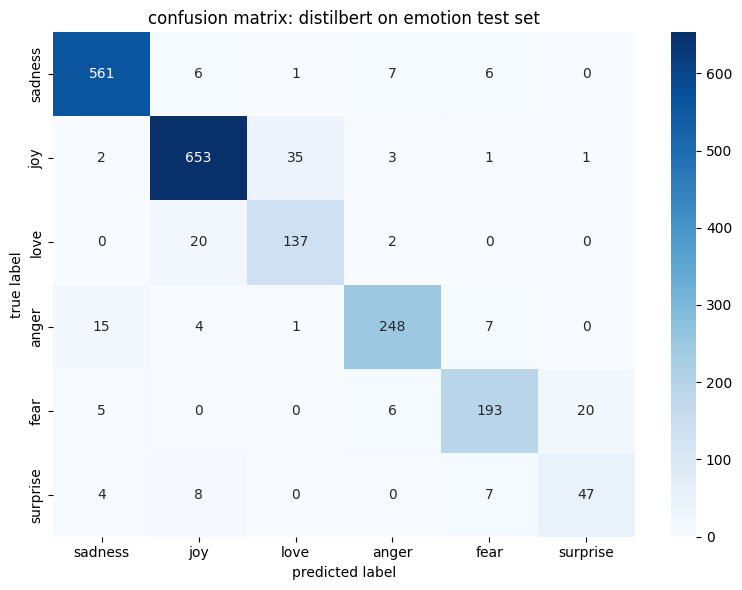

In [112]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
)
plt.title("confusion matrix: distilbert on emotion test set")
plt.xlabel("predicted label")
plt.ylabel("true label")
plt.tight_layout()
plt.show()

## references
- dataset: [dair-ai/emotion](https://huggingface.co/datasets/dair-ai/emotion)
- base model: [distilbert-base-uncased](https://huggingface.co/distilbert/distilbert-base-uncased)
- transformers training docs: [hugging face trainer](https://huggingface.co/docs/transformers/main_classes/trainer)